In [569]:
import os
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from scipy.optimize import linear_sum_assignment

In [738]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
dataset = "low_grade_glioma"
pseudobulk = True
ncells = 100000
rd = 1
# Tools: BAMixChecker, CrossCheckFingerprints, HYSYS, NGSCheckmate, Vireo

# HYSYS

In [710]:
if pseudobulk:
    hysys_df = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/concordance_output.txt", sep="\t", index_col=0, header=None)
else:
    hysys_df = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/real_data/ncells_null/read_depth_{rd}/concordance_output.txt", sep="\t", index_col=0, header=None)

In [711]:
hysys_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace(f"{dataset}/", "").replace("_individual_variants.snps", "").replace("pseudobulk/", "").replace("real_data/", "").replace(f"ncells_{ncells}/", "").replace(f"read_depth_{rd}/", ""))
    # x.replace("_filtered_variants.snps", "").replace(f"{dataset}/", "")
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [712]:
hysys_df.head()

,Sample,Concordance,Size
0,,,
GSM7326880_pseudobulk_GSM7326880_ncells_100000_1,GSM7326880_pseudobulk_GSM7326880_ncells_100000_1,1.000,1380
GSM7326880_pseudobulk_GSM7326880_ncells_100000_1,GSM7326880_pseudobulk_GSM7326880_ncells_100000_2,1.000,1380
GSM7326880_pseudobulk_GSM7326880_ncells_100000_1,GSM7326880_pseudobulk_GSM7326880_ncells_100000_3,1.000,1380
GSM7326880_pseudobulk_GSM7326880_ncells_100000_1,GSM7326881_pseudobulk_GSM7326881_ncells_100000_1,0.012,3364
GSM7326880_pseudobulk_GSM7326880_ncells_100000_1,GSM7326881_pseudobulk_GSM7326881_ncells_100000_2,0.012,3364


In [575]:
def long_df_to_matrix_hysys(df):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index=0,
        columns='Sample',
        values='Concordance',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df.index) | set(df['Sample']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [713]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [714]:
hysys_matrix.head()

,GSM7326880_pseudobulk_GSM7326880_ncells_100000_1,GSM7326880_pseudobulk_GSM7326880_ncells_100000_2,GSM7326880_pseudobulk_GSM7326880_ncells_100000_3,GSM7326881_pseudobulk_GSM7326881_ncells_100000_1,GSM7326881_pseudobulk_GSM7326881_ncells_100000_2,GSM7326881_pseudobulk_GSM7326881_ncells_100000_3,GSM7326883_pseudobulk_GSM7326883_ncells_100000_1,GSM7326883_pseudobulk_GSM7326883_ncells_100000_2,GSM7326883_pseudobulk_GSM7326883_ncells_100000_3,GSM7326884_pseudobulk_GSM7326884_ncells_100000_1,...,GSM7326901_pseudobulk_GSM7326901_ncells_100000_3,GSM7326902_pseudobulk_GSM7326902_ncells_100000_1,GSM7326902_pseudobulk_GSM7326902_ncells_100000_2,GSM7326902_pseudobulk_GSM7326902_ncells_100000_3,GSM7326903_pseudobulk_GSM7326903_ncells_100000_1,GSM7326903_pseudobulk_GSM7326903_ncells_100000_2,GSM7326903_pseudobulk_GSM7326903_ncells_100000_3,GSM7326905_pseudobulk_GSM7326905_ncells_100000_1,GSM7326905_pseudobulk_GSM7326905_ncells_100000_2,GSM7326905_pseudobulk_GSM7326905_ncells_100000_3
0,,,,,,,,,,,,,,,,,,,,,
GSM7326880_pseudobulk_GSM7326880_ncells_100000_1,1.000,1.000,1.000,0.012,0.012,0.012,0.002,0.002,0.002,0.013,...,0.003,0.003,0.003,0.003,0.002,0.002,0.002,0.001,0.001,0.001
GSM7326880_pseudobulk_GSM7326880_ncells_100000_2,1.000,1.000,1.000,0.012,0.012,0.012,0.002,0.002,0.002,0.013,...,0.003,0.003,0.003,0.003,0.002,0.002,0.002,0.001,0.001,0.001
GSM7326880_pseudobulk_GSM7326880_ncells_100000_3,1.000,1.000,1.000,0.012,0.012,0.012,0.002,0.002,0.002,0.013,...,0.003,0.003,0.003,0.003,0.002,0.002,0.002,0.001,0.001,0.001
GSM7326881_pseudobulk_GSM7326881_ncells_100000_1,0.012,0.012,0.012,1.000,1.000,1.000,0.002,0.004,0.003,0.021,...,0.006,0.004,0.003,0.004,0.006,0.006,0.006,0.001,0.001,0.001
GSM7326881_pseudobulk_GSM7326881_ncells_100000_2,0.012,0.012,0.012,1.000,1.000,1.000,0.002,0.004,0.003,0.021,...,0.006,0.004,0.003,0.004,0.006,0.006,0.006,0.001,0.001,0.001


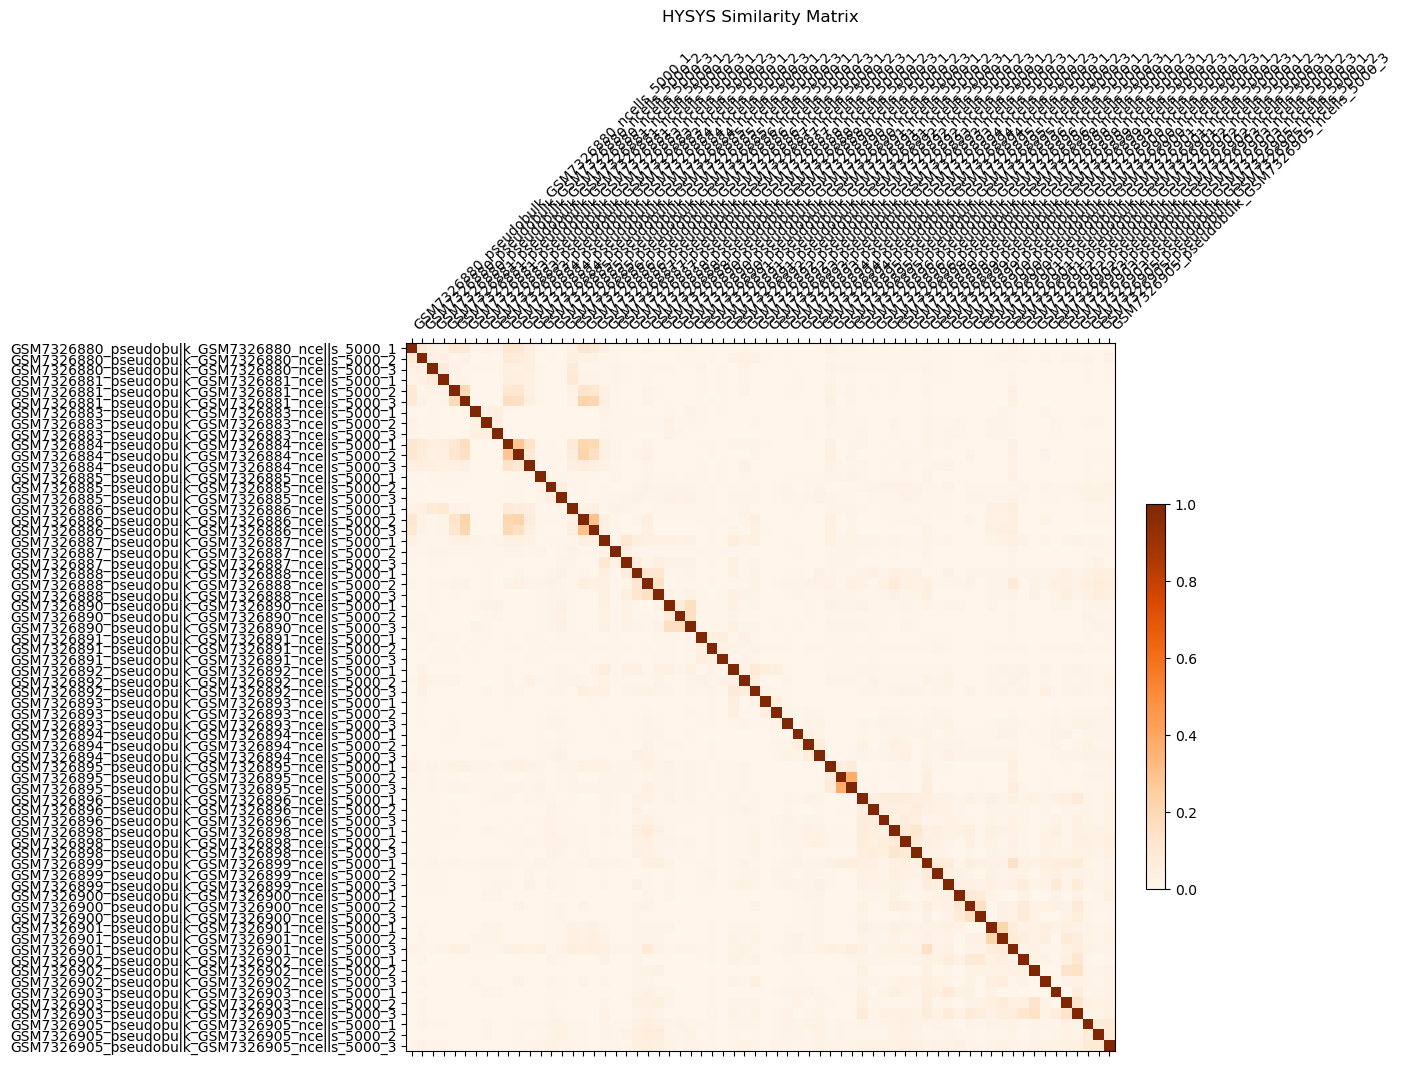

In [581]:
all_samples_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

In [580]:
# bulk_vs_singlecell_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

## Pseudobulk accuracy

In [582]:
if pseudobulk:
    hysys_matches = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/model_results.txt", sep=",", skiprows=9, header=None)
else:
    hysys_matches = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/real_data/ncells_null/read_depth_{rd}/model_results.txt", sep=",", skiprows=9, header=None)

In [583]:
hysys_matches

,0,1,2
0,reject concordance value as in between related...,low_grade_glioma/pseudobulk/ncells_5000/read_...,0.0
1,reject concordance value as in between related...,low_grade_glioma/pseudobulk/ncells_5000/read_...,0.0
2,reject concordance value as in between related...,low_grade_glioma/pseudobulk/ncells_5000/read_...,0.0
3,reject concordance value as in between related...,low_grade_glioma/pseudobulk/ncells_5000/read_...,0.0
4,reject concordance value as in between related...,low_grade_glioma/pseudobulk/ncells_5000/read_...,0.0
...,...,...,...
140,reject concordance value as in between related...,low_grade_glioma/pseudobulk/ncells_5000/read_...,0.0
141,sample low_grade_glioma/pseudobulk/ncells_5000...,NaN,NaN
142,sample low_grade_glioma/pseudobulk/ncells_5000...,NaN,NaN
143,sample low_grade_glioma/pseudobulk/ncells_5000...,NaN,NaN


In [588]:
# Clean up hysys_matches to extract sample IDs from filepaths
hysys_matches.columns = ["Sample_1", "Sample_2", "Status"]
hysys_matches["Sample_1"] = hysys_matches["Sample_1"].str.replace(r".*/(.*?)\.snps", r"\1", regex=True)
hysys_matches["Sample_2"] = hysys_matches["Sample_2"].str.replace(r".*/(.*?)\.snps", r"\1", regex=True)

# # Apply the same regex cleanup as other tools
# for col in ["Sample_1", "Sample_2"]:
#     hysys_matches[col] = [re.sub(r"[a-zA-Z0-9]{32}_", "", sample.replace("_individual_variants", "").replace("ds.", "")) for sample in hysys_matches[col]]

# hysys_matches.head()

In [602]:
def parse_hysys_model_results(file_path):
    """
    Parse HYSYS model_results.txt file to categorize sample relationships.
    
    Args:
        file_path (str): Path to the model_results.txt file
        
    Returns:
        dict: Dictionary with three categories:
            - 'matching': List of tuples (sample1, sample2) that are related
            - 'inconclusive': List of tuples (sample1, sample2) that are inconclusive
            - 'not_matching': List of tuples (sample1, sample2) that are not related
    """
    import re
    
    results = {
        'matching': [],
        'inconclusive': [],
    }
    
    with open(file_path, 'r') as file:
        content = file.read()
    
    # Clean sample names function
    def clean_sample_name(sample_path):
        # Extract filename from path
        sample_name = sample_path.split('/')[-1]
        # Remove file extension
        sample_name = sample_name.replace('.snps', '')
        # Apply same regex cleanup as other tools
        sample_name = re.sub(r"[a-zA-Z0-9]{32}_", "", sample_name)
        sample_name = sample_name.replace("_individual_variants", "").replace("ds.", "")
        return sample_name
    
    # Find all "reject concordance value" lines (inconclusive)
    reject_pattern = r"reject concordance value.*?\(([^,]+),\s*([^)]+)\)"
    reject_matches = re.findall(reject_pattern, content)
    
    for sample1_path, sample2_path in reject_matches:
        sample1 = clean_sample_name(sample1_path.strip())
        sample2 = clean_sample_name(sample2_path.strip())
        if sample1 != sample2:  # Don't include self-comparisons
            pair = tuple(sorted([sample1, sample2]))  # Sort to avoid duplicates
            if pair not in results['inconclusive']:
                results['inconclusive'].append(pair)
    
    # Find all "sample X is related to: [Y]" lines (matching)
    related_pattern = r"sample ([^\s]+) is related to: \[([^\]]+)\]"
    related_matches = re.findall(related_pattern, content)
    
    for sample1_path, related_samples_str in related_matches:
        sample1 = clean_sample_name(sample1_path.strip())
        
        # Parse the list of related samples
        related_samples = [s.strip().strip("'\"") for s in related_samples_str.split(',')]
        
        for sample2_path in related_samples:
            sample2 = clean_sample_name(sample2_path.strip())
            if sample1 != sample2:  # Don't include self-relationships
                pair = tuple(sorted([sample1, sample2]))  # Sort to avoid duplicates
                if pair not in results['matching']:
                    results['matching'].append(pair)
    
    return results

def print_hysys_results_summary(results):
    """Print a summary of HYSYS results."""
    print("HYSYS Model Results Summary:")
    print("=" * 40)
    print(f"Matching pairs: {len(results['matching'])}")
    print(f"Inconclusive pairs: {len(results['inconclusive'])}")  
    print(f"Not matching pairs: {len(results['not_matching'])}")
    print()
    
    if results['matching']:
        print("Sample pairs that match:")
        for pair in results['matching'][:10]:  # Show first 10
            print(f"  {pair[0]} ↔ {pair[1]}")
        if len(results['matching']) > 10:
            print(f"  ... and {len(results['matching']) - 10} more")
        print()
    
    if results['inconclusive']:
        print("Sample pairs that are inconclusive:")
        for pair in results['inconclusive'][:10]:  # Show first 10
            print(f"  {pair[0]} ↔ {pair[1]}")
        if len(results['inconclusive']) > 10:
            print(f"  ... and {len(results['inconclusive']) - 10} more")

In [718]:
test = parse_hysys_model_results(os.path.join(DATA_PATH, f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/model_results.txt"))

In [723]:
len(test["matching"])

2145

In [715]:
# Filter HYSYS matrix to only samples ending in _1 in rows and samples ending in _2 in columns
hysys_matrix_filtered = hysys_matrix.loc[
    [idx for idx in hysys_matrix.index if idx.endswith("_2")],
    [col for col in hysys_matrix.columns if col.endswith("_3")]
]

In [716]:
hysys_matrix_filtered.shape

(22, 22)

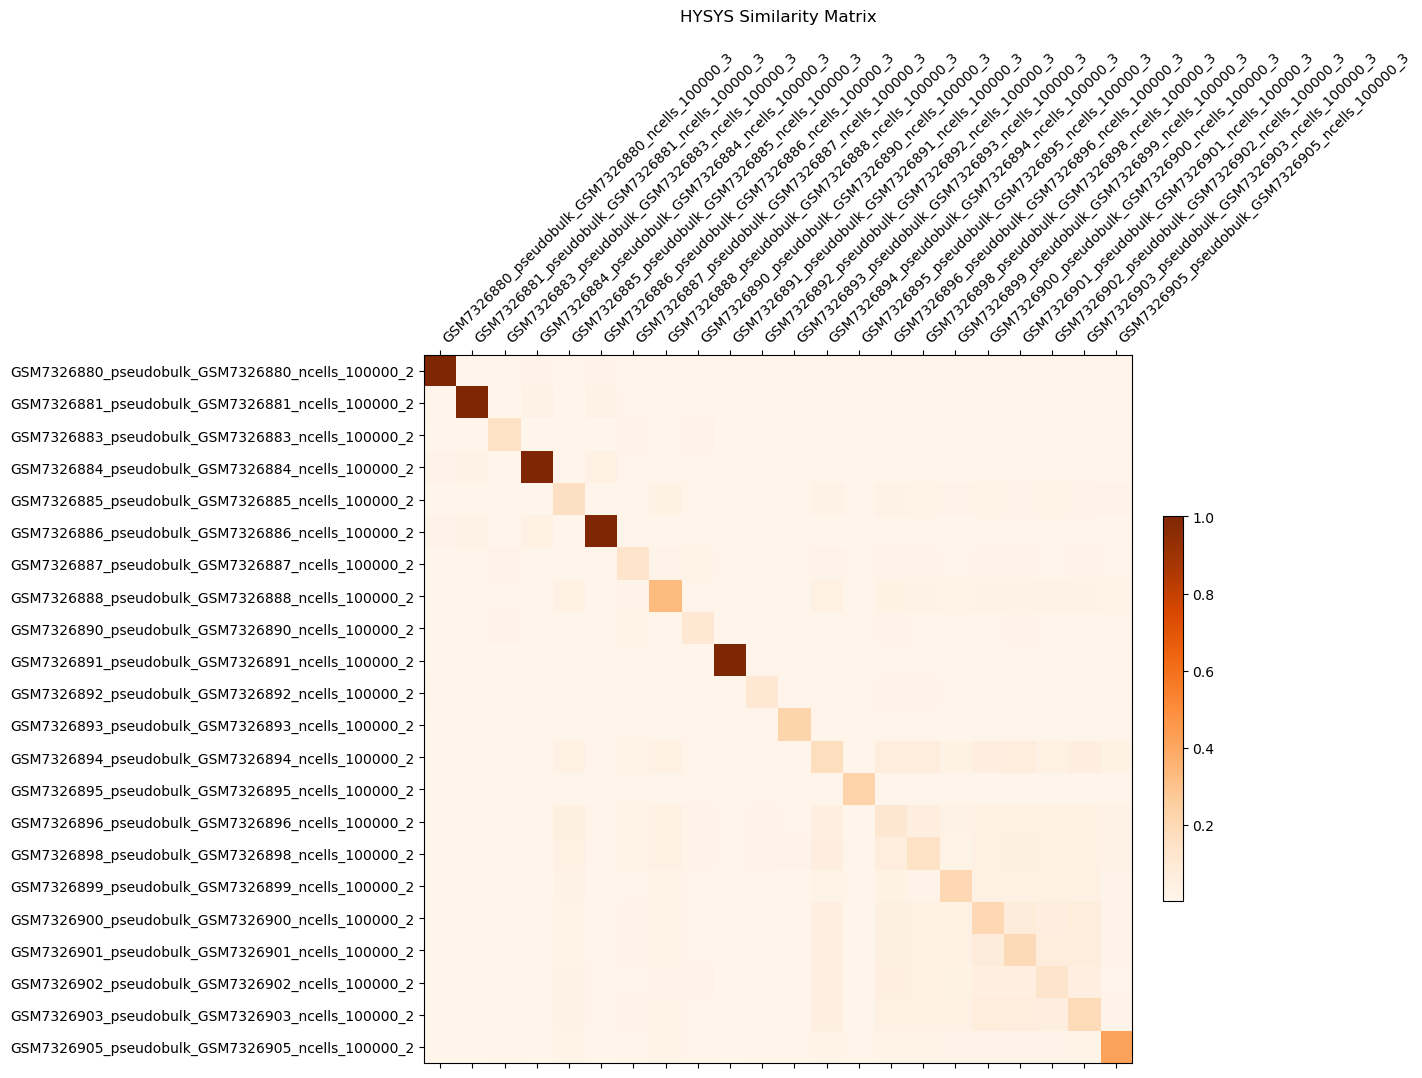

In [717]:
all_samples_matrix_viz(hysys_matrix_filtered, tool="HYSYS", dataset=dataset, save_fig=True)

# CrossCheckFingerprints

In [724]:
if pseudobulk:
    fingerprints_df = pd.read_csv(DATA_PATH + f"2a_fingerprints/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/crosscheck_metrics.txt", sep="\t", skiprows=6, header=0)
else:
    fingerprints_df = pd.read_csv(DATA_PATH + f"2a_fingerprints/{dataset}/real_data/ncells_null/read_depth_{rd}/crosscheck_metrics.txt", sep="\t", skiprows=6, header=0)
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [725]:
fingerprints_dict = {
    x: 
    # x.replace(".bam", "")
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace("ds.", ""))
    
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [726]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7326896_pseudobulk_GSM7326896_ncells_100000_2,GSM7326896_pseudobulk_GSM7326896_ncells_100000_2,8.126441,EXPECTED_MATCH
1,GSM7326896_pseudobulk_GSM7326896_ncells_100000_2,GSM7326884_pseudobulk_GSM7326884_ncells_100000_2,0.542409,UNEXPECTED_MATCH
2,GSM7326896_pseudobulk_GSM7326896_ncells_100000_2,GSM7326894_pseudobulk_GSM7326894_ncells_100000_1,0.645570,UNEXPECTED_MATCH
3,GSM7326896_pseudobulk_GSM7326896_ncells_100000_2,GSM7326899_pseudobulk_GSM7326899_ncells_100000_3,0.586132,UNEXPECTED_MATCH
4,GSM7326896_pseudobulk_GSM7326896_ncells_100000_2,GSM7326902_pseudobulk_GSM7326902_ncells_100000_2,-1.559629,EXPECTED_MISMATCH


In [644]:
def long_df_to_matrix_fingerprints(df):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index='LEFT_SAMPLE',
        columns='RIGHT_SAMPLE', 
        values='LOD_SCORE',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df['LEFT_SAMPLE']) | set(df['RIGHT_SAMPLE']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [727]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [728]:
fingerprints_matrix.head()

,GSM7326880_pseudobulk_GSM7326880_ncells_100000_1,GSM7326880_pseudobulk_GSM7326880_ncells_100000_2,GSM7326880_pseudobulk_GSM7326880_ncells_100000_3,GSM7326881_pseudobulk_GSM7326881_ncells_100000_1,GSM7326881_pseudobulk_GSM7326881_ncells_100000_2,GSM7326881_pseudobulk_GSM7326881_ncells_100000_3,GSM7326883_pseudobulk_GSM7326883_ncells_100000_1,GSM7326883_pseudobulk_GSM7326883_ncells_100000_2,GSM7326883_pseudobulk_GSM7326883_ncells_100000_3,GSM7326884_pseudobulk_GSM7326884_ncells_100000_1,...,GSM7326901_pseudobulk_GSM7326901_ncells_100000_3,GSM7326902_pseudobulk_GSM7326902_ncells_100000_1,GSM7326902_pseudobulk_GSM7326902_ncells_100000_2,GSM7326902_pseudobulk_GSM7326902_ncells_100000_3,GSM7326903_pseudobulk_GSM7326903_ncells_100000_1,GSM7326903_pseudobulk_GSM7326903_ncells_100000_2,GSM7326903_pseudobulk_GSM7326903_ncells_100000_3,GSM7326905_pseudobulk_GSM7326905_ncells_100000_1,GSM7326905_pseudobulk_GSM7326905_ncells_100000_2,GSM7326905_pseudobulk_GSM7326905_ncells_100000_3
LEFT_SAMPLE,,,,,,,,,,,,,,,,,,,,,
GSM7326880_pseudobulk_GSM7326880_ncells_100000_1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
GSM7326880_pseudobulk_GSM7326880_ncells_100000_2,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
GSM7326880_pseudobulk_GSM7326880_ncells_100000_3,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
GSM7326881_pseudobulk_GSM7326881_ncells_100000_1,0.0,0.0,0.0,0.144183,0.144183,0.144183,0.0,0.0,0.0,0.0,...,0.0,0.146396,0.146078,0.141676,0.0,0.0,0.0,0.146556,0.146556,0.146556
GSM7326881_pseudobulk_GSM7326881_ncells_100000_2,0.0,0.0,0.0,0.144183,0.144183,0.144183,0.0,0.0,0.0,0.0,...,0.0,0.146396,0.146078,0.141676,0.0,0.0,0.0,0.146556,0.146556,0.146556


In [647]:
fingerprints_matrix.shape

(66, 66)

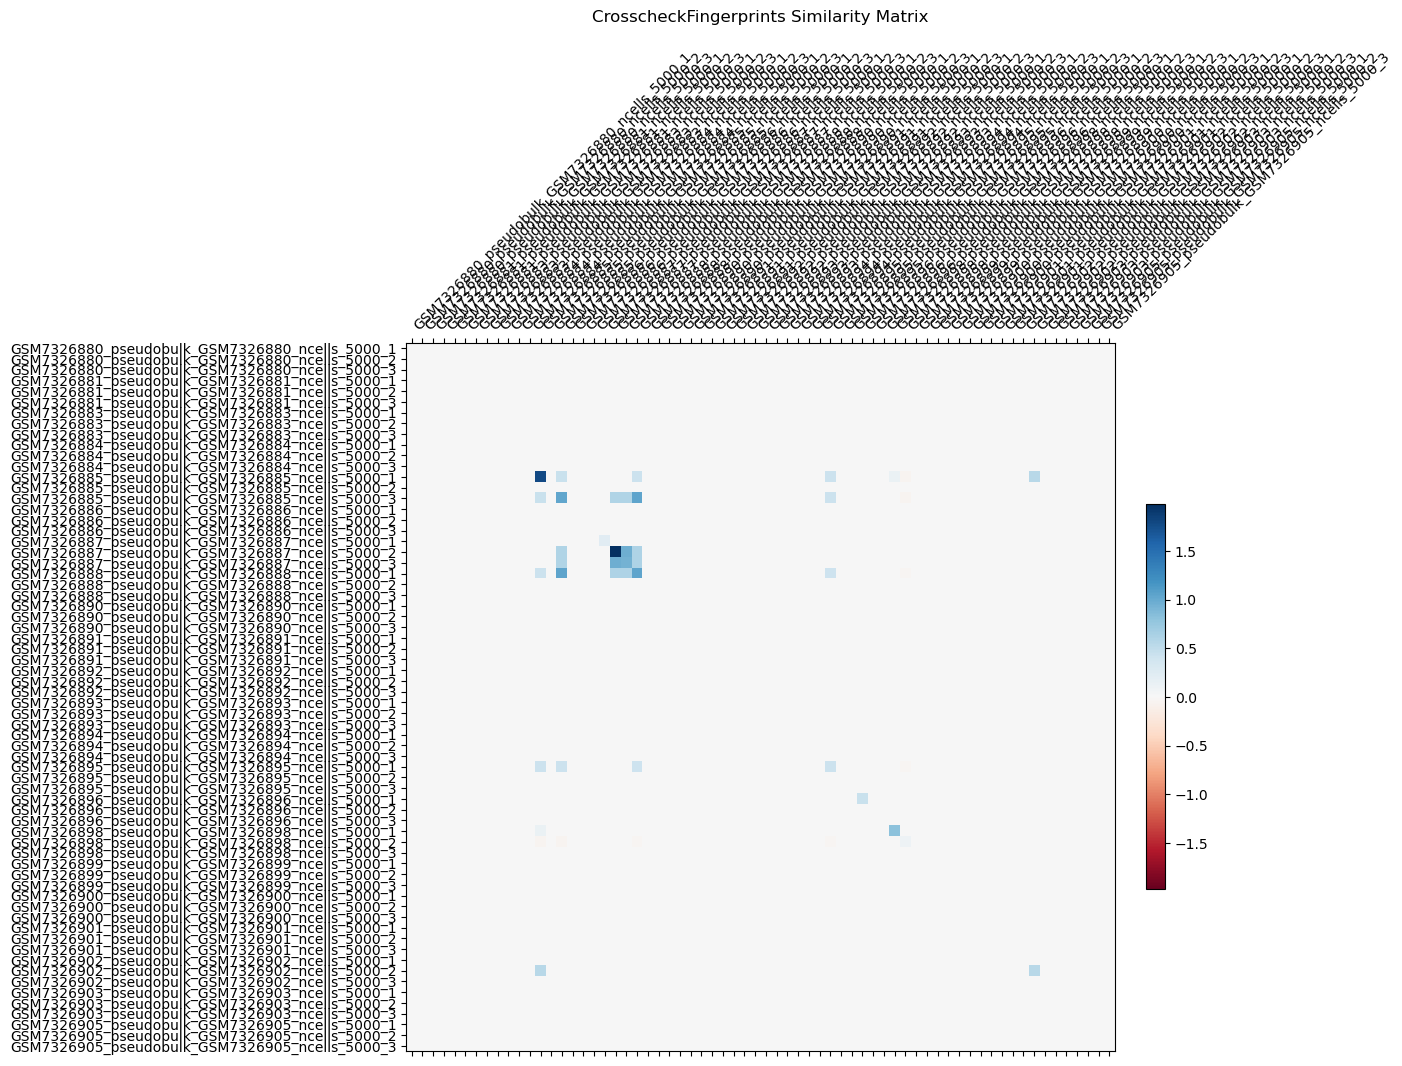

In [651]:
all_samples_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

In [650]:
# bulk_vs_singlecell_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

## Pseudobulk accuracy

In [729]:
# Filter CrosscheckFingerprints matrix to only samples ending in _1 in rows and samples ending in _2 in columns
fingerprints_matrix_filtered = fingerprints_matrix.loc[
    [idx for idx in fingerprints_matrix.index if idx.endswith("_2")],
    [col for col in fingerprints_matrix.columns if col.endswith("_3")]
]

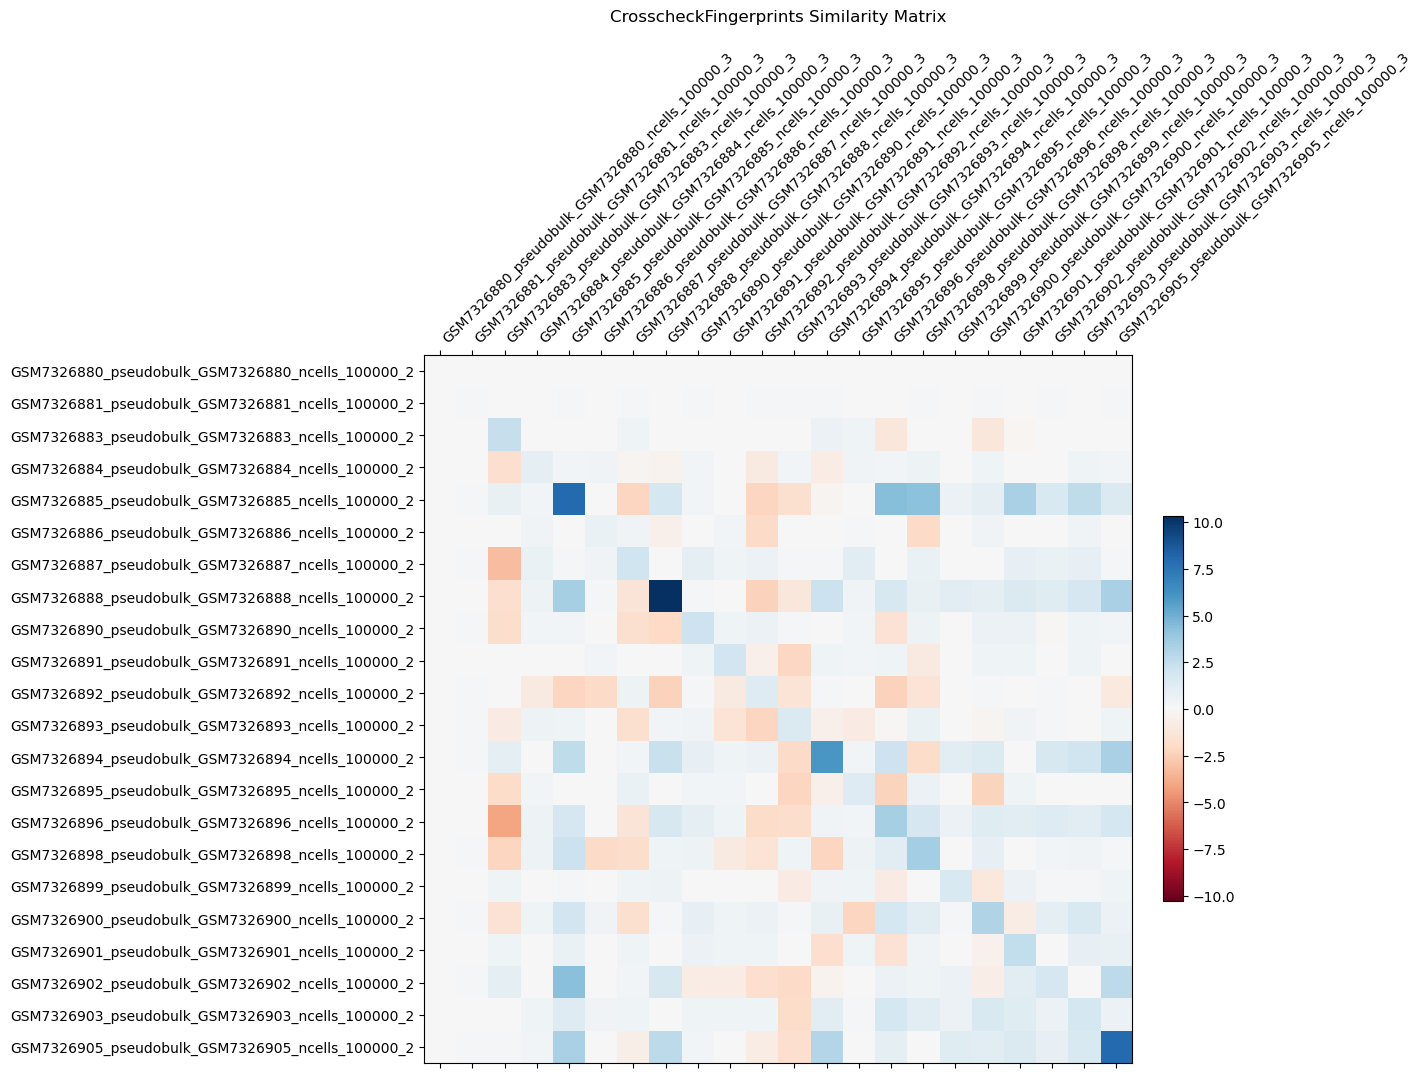

In [730]:
all_samples_matrix_viz(fingerprints_matrix_filtered, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

In [682]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7326890_pseudobulk_GSM7326890_ncells_10000_2,GSM7326890_pseudobulk_GSM7326890_ncells_10000_2,0.0,INCONCLUSIVE
1,GSM7326890_pseudobulk_GSM7326890_ncells_10000_2,GSM7326900_pseudobulk_GSM7326900_ncells_10000_2,0.0,INCONCLUSIVE
2,GSM7326890_pseudobulk_GSM7326890_ncells_10000_2,GSM7326885_pseudobulk_GSM7326885_ncells_10000_2,0.0,INCONCLUSIVE
3,GSM7326890_pseudobulk_GSM7326890_ncells_10000_2,GSM7326883_pseudobulk_GSM7326883_ncells_10000_3,0.0,INCONCLUSIVE
4,GSM7326890_pseudobulk_GSM7326890_ncells_10000_2,GSM7326892_pseudobulk_GSM7326892_ncells_10000_1,0.0,INCONCLUSIVE


In [731]:
fingerprints_df["RESULT"].value_counts()

RESULT
UNEXPECTED_MATCH     2270
INCONCLUSIVE         1257
EXPECTED_MISMATCH     766
EXPECTED_MATCH         63
Name: count, dtype: int64

In [655]:
# Confirmed that the expected matches are simply the samples matching themselves
fingerprint_exp_matches = fingerprints_df[fingerprints_df["RESULT"]=="EXPECTED_MATCH"]
fingerprint_exp_matches[fingerprint_exp_matches["LEFT_SAMPLE"] != fingerprint_exp_matches["RIGHT_SAMPLE"]]

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT


In [656]:
fingerprints_matches = fingerprints_df[fingerprints_df["RESULT"]=="UNEXPECTED_MATCH"]

In [657]:
presumed_matches_df = pd.read_csv(
    DATA_PATH + f"../metadata/sample_matches/sample_matches_{dataset}.csv"
    ).dropna(how="all", axis=1).dropna(how="any")

In [669]:
# For the UNEXPECTED_MATCH results, let's check if the let and right samples have the same sample id
fingerprints_check = fingerprints_df[fingerprints_df["RESULT"]=="UNEXPECTED_MATCH"].copy()
fingerprints_check["LEFT_SAMPLE"] = fingerprints_check["LEFT_SAMPLE"].str[:10]
fingerprints_check["RIGHT_SAMPLE"] = fingerprints_check["RIGHT_SAMPLE"].str[:10]

In [673]:
# Check how many LEFT and RIGHT samples are the same 
len(fingerprints_check[fingerprints_check["LEFT_SAMPLE"]!=fingerprints_check["RIGHT_SAMPLE"]])

22

In [662]:
fingerprints_df[fingerprints_df["RESULT"]=="UNEXPECTED_MATCH"]

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
608,GSM7326902_pseudobulk_GSM7326902_ncells_5000_2,GSM7326885_pseudobulk_GSM7326885_ncells_5000_1,0.548235,UNEXPECTED_MATCH
674,GSM7326898_pseudobulk_GSM7326898_ncells_5000_1,GSM7326885_pseudobulk_GSM7326885_ncells_5000_1,0.134334,UNEXPECTED_MATCH
933,GSM7326885_pseudobulk_GSM7326885_ncells_5000_1,GSM7326902_pseudobulk_GSM7326902_ncells_5000_2,0.548235,UNEXPECTED_MATCH
934,GSM7326885_pseudobulk_GSM7326885_ncells_5000_1,GSM7326898_pseudobulk_GSM7326898_ncells_5000_1,0.134334,UNEXPECTED_MATCH
959,GSM7326885_pseudobulk_GSM7326885_ncells_5000_1,GSM7326895_pseudobulk_GSM7326895_ncells_5000_1,0.431927,UNEXPECTED_MATCH
960,GSM7326885_pseudobulk_GSM7326885_ncells_5000_1,GSM7326888_pseudobulk_GSM7326888_ncells_5000_1,0.423130,UNEXPECTED_MATCH
968,GSM7326885_pseudobulk_GSM7326885_ncells_5000_1,GSM7326885_pseudobulk_GSM7326885_ncells_5000_3,0.438666,UNEXPECTED_MATCH
1018,GSM7326887_pseudobulk_GSM7326887_ncells_5000_3,GSM7326887_pseudobulk_GSM7326887_ncells_5000_2,0.964190,UNEXPECTED_MATCH
1026,GSM7326887_pseudobulk_GSM7326887_ncells_5000_3,GSM7326888_pseudobulk_GSM7326888_ncells_5000_1,0.613906,UNEXPECTED_MATCH
1034,GSM7326887_pseudobulk_GSM7326887_ncells_5000_3,GSM7326885_pseudobulk_GSM7326885_ncells_5000_3,0.592625,UNEXPECTED_MATCH


In [658]:
presumed_matches_df["bulk"] = presumed_matches_df["bulk"] + "_bulk"
presumed_matches_df["single-cell"] = presumed_matches_df["single-cell"] + "_single-cell"

In [659]:
presumed_matches_df

,bulk,single-cell
2,GSM7326906_bulk,GSM7326883_single-cell
5,GSM7326907_bulk,GSM7326886_single-cell
9,GSM7326908_bulk,GSM7326891_single-cell
14,GSM7326909_bulk,GSM7326896_single-cell
15,GSM7326910_bulk,GSM7326898_single-cell
17,GSM7326912_bulk,GSM7326900_single-cell
20,GSM7326913_bulk,GSM7326903_single-cell
21,GSM7326914_bulk,GSM7326905_single-cell


In [660]:
# Find all lines in fingerprints_df that have the bulk and single-cell pairs from presumed_matches_df
# Check both directions since pairs could be in either LEFT_SAMPLE/RIGHT_SAMPLE order

# Create sets for faster lookup
bulk_samples = set(presumed_matches_df["bulk"])
sc_samples = set(presumed_matches_df["single-cell"])

# Find matches in both directions
bulk_left_sc_right = fingerprints_df[
    fingerprints_df["LEFT_SAMPLE"].isin(bulk_samples) & 
    fingerprints_df["RIGHT_SAMPLE"].isin(sc_samples)
]

# Combine both directions and remove duplicates
all_presumed_matches = bulk_left_sc_right.drop_duplicates()

# Now filter to only the actual expected pairs
expected_pairs = []
for _, row in presumed_matches_df.iterrows():
    bulk_sample = row["bulk"]
    sc_sample = row["single-cell"]
    
    # Check both directions
    pair_matches = all_presumed_matches[
        ((all_presumed_matches["LEFT_SAMPLE"] == bulk_sample) & 
         (all_presumed_matches["RIGHT_SAMPLE"] == sc_sample)) |
        ((all_presumed_matches["LEFT_SAMPLE"] == sc_sample) & 
         (all_presumed_matches["RIGHT_SAMPLE"] == bulk_sample))
    ]
    expected_pairs.append(pair_matches)

presumed_pairs_results = pd.concat(expected_pairs) if expected_pairs else pd.DataFrame()

print(f"Found {len(all_presumed_matches)} total bulk-single-cell comparisons")
print(f"Found {len(presumed_pairs_results)} comparisons for the expected pairs")
print("\nExpected pairs results:")
presumed_pairs_results

Found 0 total bulk-single-cell comparisons
Found 0 comparisons for the expected pairs

Expected pairs results:


,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT


In [513]:
bulk_left_sc_right = fingerprints_df[
    fingerprints_df["LEFT_SAMPLE"].str.contains("bulk") & 
    fingerprints_df["RIGHT_SAMPLE"].str.contains("single-cell")
]

In [516]:
bulk_left_sc_right["RESULT"].value_counts()

RESULT
UNEXPECTED_MATCH     85
EXPECTED_MISMATCH    72
INCONCLUSIVE         19
Name: count, dtype: int64

In [476]:
# HGSOC
# Out of 80 unexpected matches
# There should be really only 40 pairs since it's symmetric
#
# 5/40 are polyA vs polyA (and they all involve sample 2507)
# 0 are ribo vs ribo
# 35/40 are polyA vs ribo

# CNST
# Out of 938 unexpected matches
# 
# 317/469 are bulk vs bulk
# 10/469 are sn vs sn
fingerprints_matches[
    ~(fingerprints_matches["LEFT_SAMPLE"].str.contains("bulk") & fingerprints_matches["RIGHT_SAMPLE"].str.contains("bulk")) &
    ~(fingerprints_matches["LEFT_SAMPLE"].str.contains("cell") & fingerprints_matches["RIGHT_SAMPLE"].str.contains("cell"))
].sort_values(
    by=["LEFT_SAMPLE", "RIGHT_SAMPLE"]
).drop_duplicates(
    "LOD_SCORE"
).reset_index(
    drop=True
)

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7326880_single-cell,GSM7326909_bulk,0.329098,UNEXPECTED_MATCH
1,GSM7326881_single-cell,GSM7326907_bulk,0.245428,UNEXPECTED_MATCH
2,GSM7326881_single-cell,GSM7326909_bulk,0.254490,UNEXPECTED_MATCH
3,GSM7326881_single-cell,GSM7326912_bulk,0.250071,UNEXPECTED_MATCH
4,GSM7326883_single-cell,GSM7326906_bulk,1.599053,UNEXPECTED_MATCH
...,...,...,...,...
78,GSM7326905_single-cell,GSM7326909_bulk,3.121588,UNEXPECTED_MATCH
79,GSM7326905_single-cell,GSM7326910_bulk,2.943891,UNEXPECTED_MATCH
80,GSM7326905_single-cell,GSM7326912_bulk,0.827976,UNEXPECTED_MATCH
81,GSM7326905_single-cell,GSM7326913_bulk,0.563219,UNEXPECTED_MATCH


# BAMixChecker

In [411]:
if pseudobulk:
    bamixchecker_df = pd.read_csv(DATA_PATH + f"2b_bamixchecker/{dataset}/pseudobulk/ncells_{ncells}/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
else:
    bamixchecker_df = pd.read_csv(DATA_PATH + f"2b_bamixchecker/{dataset}/real_data/ncells_null/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [412]:
bamixchecker_dict = {
    x: 
    # x.replace("_filtered_rg.bam", "") 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace("_filtered_rg.bam", "").replace(f"{dataset}/", "").replace("_filtered_variants.snps", "").replace("ds.", ""))
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [413]:
bamixchecker_df.head()

,Sample,Concordance Rate,Conclusion
0,,,
GSM7326880_single-cell,GSM7326891_single-cell,0.0,Unmatched
GSM7326880_single-cell,GSM7326884_single-cell,0.0,Unmatched
GSM7326880_single-cell,GSM7326905_single-cell,0.0,Unmatched
GSM7326880_single-cell,GSM7326899_single-cell,0.0,Unmatched
GSM7326880_single-cell,GSM7326903_single-cell,0.0,Unmatched


In [414]:
def long_df_to_matrix_bamixchecker(df):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index=0,
        columns='Sample',
        values='Concordance Rate',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df.index) | set(df['Sample']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [415]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [416]:
bamixchecker_matrix.head()

,GSM7326880_single-cell,GSM7326881_single-cell,GSM7326883_single-cell,GSM7326884_single-cell,GSM7326885_single-cell,GSM7326886_single-cell,GSM7326887_single-cell,GSM7326888_single-cell,GSM7326890_single-cell,GSM7326891_single-cell,...,GSM7326903_single-cell,GSM7326905_single-cell,GSM7326906_bulk,GSM7326907_bulk,GSM7326908_bulk,GSM7326909_bulk,GSM7326910_bulk,GSM7326912_bulk,GSM7326913_bulk,GSM7326914_bulk
0,,,,,,,,,,,,,,,,,,,,,
GSM7326880_single-cell,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7326881_single-cell,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7326883_single-cell,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7326884_single-cell,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7326885_single-cell,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# all_samples_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

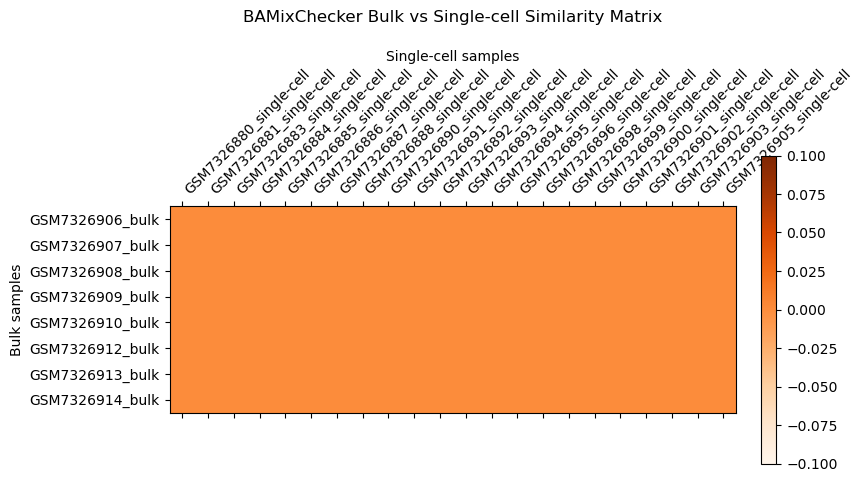

In [417]:
bulk_vs_singlecell_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

# Tool comparison

In [ ]:
venn2(subsets=(28, 28, 8), set_labels=('BAMixChecker \nCrosscheckFingerprints \nHYSYS \nVireo ', 'NGSCheckmate'))
plt.title("Agreement between tools")
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.png", bbox_inches="tight", dpi=300)
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.pdf", bbox_inches="tight", dpi=300